# RPA Model Class

A generic `RPAModel` class for the six SN5.2 networks from Araujo & Liotta (2018).

Each model is defined once — ODE equations written in **SymPy**, base parameter values, and the output variable name. Everything else is automatic:
- Steady-state O* is solved analytically.
- RPA parameters (∂O*/∂k = 0) are identified by symbolic differentiation.
- A `scipy`-compatible ODE is produced via `lambdify`.

The test suite validates the RPA parameter list numerically.

In [187]:
import numpy as np
from scipy.integrate import solve_ivp
from sympy import symbols, solve, simplify, diff, lambdify

In [188]:
class RPAModel:
    """
    RPA ODE model defined symbolically with SymPy.

    Parameters
    ----------
    name        : short label
    state_vars  : ordered list of state-variable name strings
    output_var  : name of the output variable (must appear in state_vars)
    params_base : dict of base values for every parameter, including 'Input'
    equations   : list of sympy expressions — the RHS of dxi/dt in the same
                  order as state_vars, written using symbols whose names match
                  state_vars and params_base keys (all declared positive=True)

    Attributes set automatically
    ----------------------------
    O_star_sym  : sympy expression for the analytic steady-state of output_var
    rpa_params  : list of parameter names with ∂O*/∂k = 0, including 'Input'
                  when O* is independent of the input signal
    """

    def __init__(self, name, state_vars, output_var, params_base, equations):
        self.name        = name
        self.state_vars  = list(state_vars)
        self.output_var  = output_var
        self.output_idx  = self.state_vars.index(output_var)
        self.params_base = dict(params_base)
        self._equations  = list(equations)

        self._sym_state   = [symbols(v, positive=True) for v in state_vars]
        self._param_names = [k for k in params_base if k != 'Input']
        self._sym_params  = [symbols(k, positive=True) for k in self._param_names]
        self._sym_input   = symbols('Input', positive=True)

        # ── 1. analytic steady state ──────────────────────────────────────
        self._ss_dict   = self._solve_ss()
        O_sym           = self._sym_state[self.output_idx]
        self.O_star_sym = simplify(self._ss_dict[O_sym])

        # ── 2. RPA parameters: ∂O*/∂k = 0 ────────────────────────────────
        self.rpa_params = [
            name for name, sym in zip(self._param_names, self._sym_params)
            if diff(self.O_star_sym, sym) == 0
        ]
        # Input is also an RPA parameter when O* does not depend on it
        if diff(self.O_star_sym, self._sym_input) == 0:
            self.rpa_params.append('Input')

        # ── 3. lambdify ODE once ──────────────────────────────────────────
        _args       = self._sym_state + self._sym_params + [self._sym_input]
        self._f_lam = lambdify(_args, self._equations, modules='numpy')

    # ── private ───────────────────────────────────────────────────────────────

    def _solve_ss(self):
        sols = solve(self._equations, self._sym_state, dict=True)
        if not sols:
            raise ValueError(f"[{self.name}] No analytic steady-state found.")
        return sols[0]

    # ── public API ────────────────────────────────────────────────────────────

    def get_f(self, rpa_overrides=None):
        """Return f(t, y) → dydt for scipy.integrate.solve_ivp."""
        p     = dict(self.params_base)
        if rpa_overrides:
            p.update(rpa_overrides)
        pvals  = [p[k] for k in self._param_names] + [p['Input']]
        f_lam  = self._f_lam
        def f(t, y):
            return f_lam(*y, *pvals)
        return f

    def _repr_latex_(self):
        from sympy import latex as sym_latex

        # ODE rows — aligned at '='
        ode_rows = r' \\'.join(
            r'\dot{' + sym_latex(sv) + r'} &= ' + sym_latex(eq)
            for sv, eq in zip(self._sym_state, self._equations)
        )

        # Steady-state row
        O_sym   = self._sym_state[self.output_idx]
        ss_row  = sym_latex(O_sym) + r'^{*} &= ' + sym_latex(self.O_star_sym)

        # RPA params row
        rpa_str = r',\;'.join(
            r'\text{Input}' if p == 'Input' else sym_latex(symbols(p, positive=True))
            for p in self.rpa_params
        )
        rpa_row = r'\text{RPA params} &:\; ' + rpa_str

        body = (
            r'& \textbf{Case\;' + self.name + r'} \\[4pt]'
            + ode_rows
            + r' \\[6pt]'
            + ss_row
            + r' \\[6pt]'
            + rpa_row
        )
        return r'$$\begin{aligned}' + body + r'\end{aligned}$$'

    def __repr__(self):
        return (f"RPAModel('{self.name}', output='{self.output_var}', "
                f"rpa_params={self.rpa_params})")

## Model definitions (cases a – f)

Each model is fully specified by its **SymPy equations** and **base parameter values**.  
`rpa_params` and `O_star_sym` are derived automatically — no hand-annotation required.

> **Symbol note:** the biochemical signal node named *I* is written as the Python variable `Iv`  
> (holding `Symbol('I', positive=True)`) to avoid shadowing SymPy's imaginary unit.

In [189]:
# ── shared symbols ────────────────────────────────────────────────────────────
# State-variable symbols.  Iv = Symbol('I', positive=True) — the signal node.
Iv, O, O1, O2, O3 = symbols('I  O  O1  O2  O3', positive=True)
B,  C,  X,  X1, X2 = symbols('B  C  X   X1  X2', positive=True)

Input_sym = symbols('Input', positive=True)

# All 18 kinetic-parameter symbols used across all cases
(k1, k2, k3, k4, k5, k6, k7, k8, k9,
 k10, k11, k12, k13, k14, k15, k16, k17, k18) = symbols(
    'k1 k2 k3 k4 k5 k6 k7 k8 k9 k10 k11 k12 k13 k14 k15 k16 k17 k18',
    positive=True)

# ── Case a ────────────────────────────────────────────────────────────────────
# Opposer module (upstream) + Balancer module (downstream)
model_a = RPAModel(
    name='a',
    state_vars=['I', 'O', 'O1', 'C', 'B'],
    output_var='O',
    params_base=dict(Input=1.0,
                     k1=1.0, k2=0.5, k3=1.0, k4=0.5, k5=0.5, k6=1.0,
                     k7=1.0, k8=0.5, k9=0.5, k10=0.5, k11=0.5, k12=0.5),
    equations=[
        k1*Input_sym - k2*Iv  - k3*O1,
        k4*Iv        + k5*C   - k6*O,
        k7*Iv        - k8,
        k9*O1        - k10*B*C,
        k11*O1       - k12*B,          # PDF has +k12*B (sign typo)
    ]
)

# ── Case b ────────────────────────────────────────────────────────────────────
# Balancer module (upstream) + Opposer module (downstream)
model_b = RPAModel(
    name='b',
    state_vars=['I', 'B', 'X', 'O1', 'O'],
    output_var='O',
    params_base=dict(Input=1.0,
                     k1=1.0, k2=1.0, k3=1.0, k4=1.0, k5=0.5,
                     k7=1.0, k8=1.0, k9=0.5, k10=1.0, k11=1.0),
    equations=[
        k1*Input_sym - k2*Iv,
        k3*Iv        - k4*B,
        k5*B / O1    - k7*X,
        k8*X         - k9,
        k10*Iv*X     - k11*O*B,
    ]
)

# ── Case c ────────────────────────────────────────────────────────────────────
# Two Opposer modules in series
model_c = RPAModel(
    name='c',
    state_vars=['I', 'O', 'O1', 'X', 'O2'],
    output_var='O',
    params_base=dict(Input=1.0,
                     k1=1.0, k2=0.5, k3=1.0, k4=0.5, k5=0.5, k6=1.0,
                     k7=1.0, k8=0.5, k9=0.5, k10=0.5, k11=0.5, k12=1.0, k13=0.5),
    equations=[
        k1*Input_sym - k2*Iv  - k3*O1,
        k4*Iv        + k5*X   - k6*O,
        k7*Iv        - k8,
        k9*O1        - k10*X  - k11*O2,
        k12*X        - k13,
    ]
)

# ── Case d ────────────────────────────────────────────────────────────────────
# Single Opposer module with two-node opposing set
model_d = RPAModel(
    name='d',
    state_vars=['I', 'O', 'O1', 'X', 'O2'],
    output_var='O',
    params_base=dict(Input=1.0,
                     k1=0.5, k2=0.5, k3=0.5, k4=1.0, k5=1.0, k6=1.0,
                     k7=1.0, k8=1.0, k9=0.5, k10=1.0, k11=1.0, k12=0.5),
    equations=[
        k1*Input_sym - k2*Iv  - k3*O1,
        k4*Iv        - k5*O,
        k11*X        - k12,
        k8*O2        - k9*X   - k10*O1,
        k6*O         - k7*X,
    ]
)

# ── Case e ────────────────────────────────────────────────────────────────────
# Opposer module (upstream, two-node set) + Balancer module (downstream)
model_e = RPAModel(
    name='e',
    state_vars=['I', 'O1', 'X', 'O2', 'B', 'C', 'O'],
    output_var='O',
    params_base=dict(Input=1.0,
                     k1=0.5, k2=1.0, k4=1.0, k5=1.0, k6=1.0, k7=1.0, k8=0.4,
                     k9=1.0, k10=0.5, k11=1.0, k12=1.0, k14=0.5, k15=1.0,
                     k16=0.5, k17=0.5, k18=1.0),
    equations=[
        k1*Input_sym - k2*O1*Iv,
        k4*Iv        - k5*X,
        k6*O1        - k7*O2  - k8*X,
        k9*X         - k10,
        k11*O2       - k12*B,
        k14*O2       - k15*B*C,
        k16*Iv       + k17*C  - k18*O,
    ]
)

# ── Case f ────────────────────────────────────────────────────────────────────
# Opposer module (upstream, two-node set) + Opposer module (downstream, single node)
model_f = RPAModel(
    name='f',
    state_vars=['I', 'O1', 'X1', 'O2', 'X2', 'O3', 'O'],
    output_var='O',
    params_base=dict(Input=1.0,
                     k1=0.5, k2=0.5, k3=0.5, k4=1.0, k5=1.0, k6=1.0, k7=1.0,
                     k8=1.0, k9=1.0, k10=0.5, k11=1.0, k12=0.5, k13=1.0,
                     k14=1.0, k15=0.5, k16=0.5, k17=0.5, k18=1.0),
    equations=[
        k1*Input_sym - k2*Iv   - k3*O1,
        k4*Iv        - k5*X1,
        k6*O1        - k7*O2   - k8*X1,
        k9*X1        - k10,
        k11*O2       - k12*X2  - k13*O3,
        k14*X2       - k15,
        k16*Iv       + k17*X2  - k18*O,
    ]
)

ALL_MODELS = [model_a, model_b, model_c, model_d, model_e, model_f]
for m in ALL_MODELS:
    print(m)

RPAModel('a', output='O', rpa_params=['k1', 'k2', 'k3', 'Input'])
RPAModel('b', output='O', rpa_params=['k1', 'k2', 'k5', 'k7', 'Input'])
RPAModel('c', output='O', rpa_params=['k1', 'k2', 'k3', 'k9', 'k10', 'k11', 'Input'])
RPAModel('d', output='O', rpa_params=['k1', 'k2', 'k3', 'k4', 'k5', 'k8', 'k9', 'k10', 'Input'])
RPAModel('e', output='O', rpa_params=['k1', 'k2', 'k6', 'k7', 'k8', 'Input'])
RPAModel('f', output='O', rpa_params=['k1', 'k2', 'k3', 'k6', 'k7', 'k8', 'k11', 'k12', 'k13', 'Input'])


In [190]:
# ── Integral-feedback model ───────────────────────────────────────────────────
# dA/dt = α(μ - B)
# dB/dt = β₁ A - β₂ B
#
# μ ≡ Input (the reference/set-point).
# Steady state: B* = μ = Input  (independent of α, β₁, β₂  →  all are RPA params)

A               = symbols('A',               positive=True)
alpha, beta1, beta2 = symbols('alpha beta1 beta2', positive=True)

model_if = RPAModel(
    name='IF',
    state_vars=['A', 'B'],
    output_var='B',
    params_base=dict(Input=1.0, alpha=10.0, beta1=10.0, beta2=1.0),
    equations=[
        alpha * (Input_sym - B),   # dA/dt = α(μ − B)
        beta1 * A - beta2 * B,     # dB/dt = β₁A − β₂B
    ]
)

display(model_if)

RPAModel('IF', output='B', rpa_params=['alpha', 'beta1', 'beta2'])

In [191]:
# ── IFFL model ────────────────────────────────────────────────────────────────
# dx/dt = α·u − δ·x
# dy/dt = β·u − γ·x·y
#
# Steady state: x* = α·u/δ,  y* = βδ/(γα)  — independent of u  →  RPA

x_s, y_s                   = symbols('x y',           positive=True)
delta_s, beta_s, gamma_s   = symbols('delta beta gamma', positive=True)
# alpha is already declared from the IF model cell

model_iffl = RPAModel(
    name='IFFL',
    state_vars=['x', 'y'],
    output_var='y',
    params_base=dict(Input=1.0, alpha=1.0, delta=1.0, beta=1.0, gamma=1.0),
    equations=[
        alpha   * Input_sym - delta_s * x_s,
        beta_s  * Input_sym - gamma_s * x_s * y_s,
    ]
)

display(model_iffl)

RPAModel('IFFL', output='y', rpa_params=['Input'])

In [192]:
from IPython.display import display
for model in ALL_MODELS:
    display(model)

RPAModel('a', output='O', rpa_params=['k1', 'k2', 'k3', 'Input'])

RPAModel('b', output='O', rpa_params=['k1', 'k2', 'k5', 'k7', 'Input'])

RPAModel('c', output='O', rpa_params=['k1', 'k2', 'k3', 'k9', 'k10', 'k11', 'Input'])

RPAModel('d', output='O', rpa_params=['k1', 'k2', 'k3', 'k4', 'k5', 'k8', 'k9', 'k10', 'Input'])

RPAModel('e', output='O', rpa_params=['k1', 'k2', 'k6', 'k7', 'k8', 'Input'])

RPAModel('f', output='O', rpa_params=['k1', 'k2', 'k3', 'k6', 'k7', 'k8', 'k11', 'k12', 'k13', 'Input'])

## RPA parameter validation

For each model and each declared RPA parameter, we run the ODE twice — at the base value and at `scale × base` — and verify that the output O reaches the same steady state (relative difference < `ss_tol`). `Input` is also tested as the primary RPA check.

In [193]:
def validate_rpa_params(model, scale=2.0, t_end=500, ss_tol=1e-2,
                        rtol=1e-10, atol=1e-12):
    """
    For every declared RPA parameter (including 'Input' if not already in
    rpa_params), run the ODE at the base value and at scale*base value.
    Both runs start from the same initial condition y0 = 0.5 * ones and
    integrate to t_end.  A test passes when the relative difference in the
    final O value is below ss_tol.

    Returns
    -------
    dict mapping param_name -> {base_val, test_val, O_base, O_scaled,
                                 rel_diff, passed}
    """
    # Include 'Input' only if it is not already in rpa_params
    params_to_test = (model.rpa_params if 'Input' in model.rpa_params
                      else model.rpa_params + ['Input'])

    y0   = np.ones(len(model.state_vars)) * 0.5
    kw   = dict(method='Radau', rtol=rtol, atol=atol, dense_output=False)

    sol_base = solve_ivp(model.get_f(), (0, t_end), y0, **kw)
    assert sol_base.success, f"Base integration failed for model {model.name}"
    O_base = sol_base.y[model.output_idx, -1]

    results = {}
    for param in params_to_test:
        base_val = model.params_base[param]
        test_val = base_val * scale
        sol = solve_ivp(model.get_f({param: test_val}), (0, t_end), y0, **kw)
        assert sol.success, f"Integration failed for model {model.name}, {param}={test_val}"
        O_test   = sol.y[model.output_idx, -1]
        rel_diff = abs(O_test - O_base) / abs(O_base)
        results[param] = dict(
            base_val = base_val,
            test_val = test_val,
            O_base   = O_base,
            O_scaled = O_test,
            rel_diff = rel_diff,
            passed   = rel_diff < ss_tol,
        )
    return results


def print_results(model, results):
    n_pass = sum(r['passed'] for r in results.values())
    n_total = len(results)
    tag = 'PASS' if n_pass == n_total else 'FAIL'
    print(f"[{tag}] Case {model.name}  ({n_pass}/{n_total} params)")
    for param, r in results.items():
        mark = '✓' if r['passed'] else '✗'
        print(f"  {mark} {param:5s}  base={r['base_val']:.3f} → {r['test_val']:.3f}"
              f"  |  O*= {r['O_base']:.5f}  vs  {r['O_scaled']:.5f}"
              f"  (rel Δ = {r['rel_diff']:.1e})")

In [194]:
# for model in ALL_MODELS:
#     results = validate_rpa_params(model)
#     print_results(model, results)
#     print()

## Resonance Strategy

Parametric resonance control for an RPA model. For each RPA parameter, two variants are created (2× and 0.5× baseline). Both assignments are simulated independently — producing two trajectories per RPA parameter:

- **hard = 2×, soft = 0.5×**: the larger-parameter variant drives return to equilibrium
- **hard = 0.5×, soft = 2×**: the smaller-parameter variant drives return to equilibrium

At each simulation, switching occurs at:
- **dO/dt = 0** — output at a local extremum
- **O = O\*** — output crossing its equilibrium

In [195]:
import matplotlib.pyplot as plt

class ResonanceStrategy:
    """
    Parametric resonance strategy for an RPAModel.

    For each RPA parameter two variants are created:
        '2x'   — parameter set to 2 × baseline
        '0.5x' — parameter set to 0.5 × baseline

    At each RK4 step the spring is chosen from the current O and dO/dt:
        hard  when O is moving toward  O*   (accelerate return)
        soft  when O is moving away from O* (reduce overshoot)

    Attributes
    ----------
    variants  : {param: {'2x': overrides_dict, '0.5x': overrides_dict}}
    O_star    : float — steady-state output value at base parameters
    results   : {param: {'2x': result_dict, '0.5x': result_dict}}
    """

    def __init__(self, model):
        self.model    = model
        self.baseline = dict(model.params_base)
        self._oidx    = model.output_idx

        self.variants = {
            param: {
                '2x':   {param: self.baseline[param] * 2.0},
                '0.5x': {param: self.baseline[param] * 0.5},
            }
            for param in model.rpa_params
        }

        self.O_star = float(self._eval_ss()[self._oidx])
        self.results = {}

    # ── private helpers ───────────────────────────────────────────────────────

    def _eval_ss(self, overrides=None):
        p = dict(self.baseline)
        if overrides:
            p.update(overrides)
        subs = {sym: p[name]
                for name, sym in zip(self.model._param_names, self.model._sym_params)}
        subs[self.model._sym_input] = p['Input']
        return np.array([float(self.model._ss_dict[s].subs(subs))
                         for s in self.model._sym_state])

    def _get_f(self, param, key):
        return self.model.get_f(self.variants[param][key])

    # ── simulation ────────────────────────────────────────────────────────────

    def simulate(self, param, hard_key='2x', t_end=500, perturb_factor=1.3,
                 dt=0.005, min_dwell=0.0):
        """
        Fixed-step RK4 simulation with adaptive spring switching.

        At every step the spring is chosen based on O vs O* and sign of dO/dt.
        min_dwell sets a minimum time (in model time units) that must elapse
        between consecutive switches, preventing rapid chattering.
        """
        soft_key   = '0.5x' if hard_key == '2x' else '2x'
        oidx       = self._oidx
        O_star     = self.O_star
        hard_val   = self.baseline[param] * (2.0 if hard_key == '2x' else 0.5)
        soft_val   = self.baseline[param] * (0.5 if hard_key == '2x' else 2.0)

        f_hard = self._get_f(param, hard_key)
        f_soft = self._get_f(param, soft_key)

        y0         = self._eval_ss(self.variants[param][hard_key]).copy()
        y0[oidx]  *= perturb_factor

        n_steps      = int(round(t_end / dt))
        dwell_steps  = int(round(min_dwell / dt))
        t_arr        = np.linspace(0, t_end, n_steps + 1)
        y_arr        = np.zeros((len(y0), n_steps + 1))
        y_arr[:, 0]  = y0
        ctrl         = np.zeros(n_steps + 1)

        switches          = []
        prev_key          = None
        use_hard          = True
        steps_since_switch = dwell_steps  # allow immediate first switch

        for i in range(n_steps):
            y_i    = y_arr[:, i]
            O_i    = y_i[oidx]
            dOdt_i = f_hard(t_arr[i], y_i)[oidx]

            # Desired spring based on direction of motion
            if O_i > O_star:
                desired_hard = dOdt_i < 0
            else:
                desired_hard = dOdt_i > 0

            # Only switch if dwell time has elapsed
            if desired_hard != use_hard and steps_since_switch >= dwell_steps:
                use_hard           = desired_hard
                steps_since_switch = 0

            key     = hard_key if use_hard else soft_key
            ctrl[i] = hard_val if use_hard else soft_val

            if key != prev_key:
                if prev_key is not None:
                    switches.append((t_arr[i], prev_key, key))
                prev_key = key

            f_cur = f_hard if use_hard else f_soft
            t_i   = t_arr[i]
            k1 = np.array(f_cur(t_i,          y_i))
            k2 = np.array(f_cur(t_i + 0.5*dt, y_i + 0.5*dt*k1))
            k3 = np.array(f_cur(t_i + 0.5*dt, y_i + 0.5*dt*k2))
            k4 = np.array(f_cur(t_i + dt,      y_i +      dt*k3))
            y_arr[:, i+1] = y_i + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

            steps_since_switch += 1

        ctrl[-1] = ctrl[-2]

        self.results.setdefault(param, {})[hard_key] = {
            't':        t_arr,
            'y':        y_arr,
            'ctrl':     ctrl,
            'switches': switches,
            'O_star':   O_star,
            'hard_key': hard_key,
            'soft_key': soft_key,
            'hard_val': hard_val,
            'soft_val': soft_val,
        }
        return t_arr, y_arr

    def simulate_all(self, **kwargs):
        """Run both variants for every RPA parameter."""
        for param in self.model.rpa_params:
            for hard_key in ('2x', '0.5x'):
                print(f"  param={param}  hard={hard_key} ...")
                self.simulate(param, hard_key=hard_key, **kwargs)
        print("Done.")

In [196]:
import matplotlib.patches as mpatches

def run_resonance_demo(model, t_end=10, perturb_factor=1.3, dt=0.005, min_dwell=0.0):
    """
    Build a ResonanceStrategy for `model`, simulate both variants (hard='2x'
    and hard='0.5x') for every RPA parameter, and plot O(t) with spring shading.

    Layout: n_params rows × 2 columns.
      Left column  — hard = 2×, soft = 0.5×
      Right column — hard = 0.5×, soft = 2×

    Returns the ResonanceStrategy instance.
    """
    rs = ResonanceStrategy(model)
    print(f"Model {model.name}  |  O* = {rs.O_star:.4f}  |  "
          f"RPA params: {model.rpa_params}\n")
    rs.simulate_all(t_end=t_end, perturb_factor=perturb_factor, dt=dt,
                    min_dwell=min_dwell)

    n = len(model.rpa_params)
    fig, axes = plt.subplots(n, 2, figsize=(14, 3.5 * n), sharex=False)
    if n == 1:
        axes = axes.reshape(1, 2)

    for row, param in enumerate(model.rpa_params):
        for col, hard_key in enumerate(('2x', '0.5x')):
            ax       = axes[row, col]
            res      = rs.results[param][hard_key]
            t        = res['t']
            y        = res['y']
            ctrl     = res['ctrl']
            oidx     = model.output_idx
            hard_val = res['hard_val']
            soft_val = res['soft_val']

            # Shade background using ctrl array
            is_hard = np.isclose(ctrl, hard_val)
            changes = np.where(np.diff(is_hard.astype(int)) != 0)[0]
            bounds  = np.concatenate([[0], changes + 1, [len(t) - 1]])
            for j in range(len(bounds) - 1):
                i0, i1 = bounds[j], bounds[j + 1]
                color  = '#e8c4a0' if is_hard[i0] else '#c4d8e8'
                ax.axvspan(t[i0], t[i1], alpha=0.25, color=color, lw=0)

            ax.plot(t, y[oidx], color='steelblue', lw=1.5)
            ax.axhline(res['O_star'], color='k', ls='--', lw=1)

            ax.legend(handles=[
                plt.Line2D([0], [0], color='steelblue', lw=1.5,
                           label=f'O(t)'),
                plt.Line2D([0], [0], color='k', ls='--', lw=1,
                           label=f"O* = {res['O_star']:.3f}"),
                mpatches.Patch(facecolor='#e8c4a0', alpha=0.5,
                               label=f'toward O*: {param} = {hard_val:.3g}'),
                mpatches.Patch(facecolor='#c4d8e8', alpha=0.5,
                               label=f'away from O*: {param} = {soft_val:.3g}'),
            ], fontsize=7.5)

            ax.set_title(
                f"param = {param}  |  hard = {hard_key} ({hard_val:.3g}),  "
                f"soft = {'0.5x' if hard_key == '2x' else '2x'} ({soft_val:.3g})  "
                f"|  {len(res['switches'])} switches",
                fontsize=9)
            ax.set_xlabel('time')
            ax.set_ylabel('O')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

    fig.suptitle(f'Resonance strategy — model {model.name}', fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()
    return rs

Model d  |  O* = 0.5000  |  RPA params: ['k1', 'k2', 'k3', 'k4', 'k5', 'k8', 'k9', 'k10', 'Input']

  param=k1  hard=2x ...
  param=k1  hard=0.5x ...
  param=k2  hard=2x ...
  param=k2  hard=0.5x ...
  param=k3  hard=2x ...
  param=k3  hard=0.5x ...
  param=k4  hard=2x ...
  param=k4  hard=0.5x ...
  param=k5  hard=2x ...
  param=k5  hard=0.5x ...
  param=k8  hard=2x ...
  param=k8  hard=0.5x ...
  param=k9  hard=2x ...
  param=k9  hard=0.5x ...
  param=k10  hard=2x ...
  param=k10  hard=0.5x ...
  param=Input  hard=2x ...
  param=Input  hard=0.5x ...
Done.


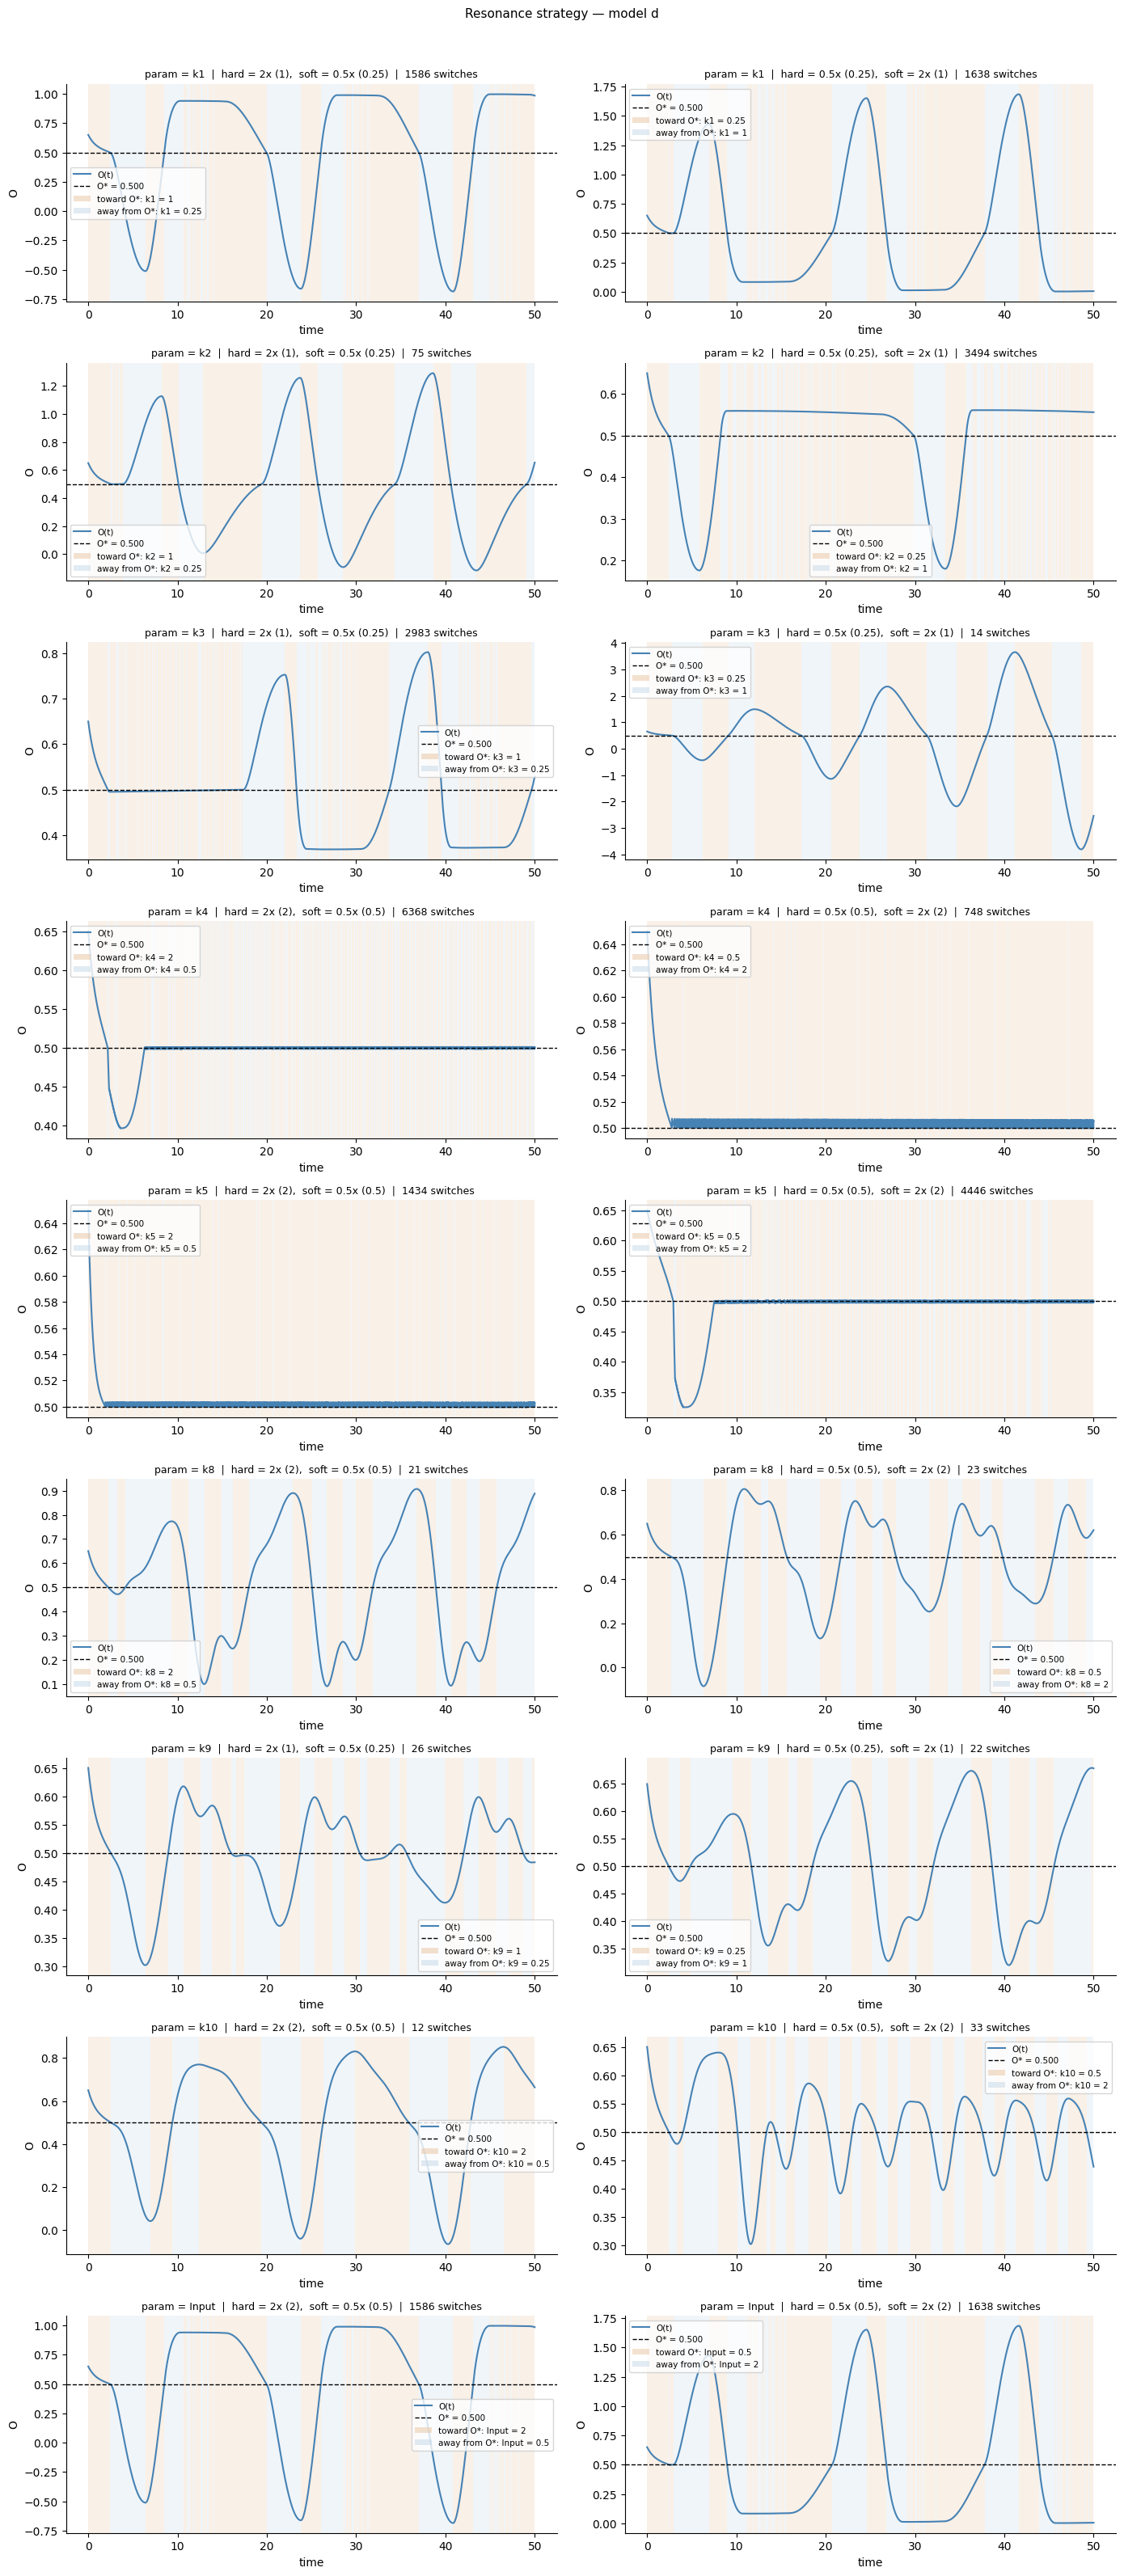

In [209]:
rs = run_resonance_demo(model_d, t_end=50)
# rs = run_resonance_demo(model_c)

/tmp/ipykernel_729265/1503112492.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


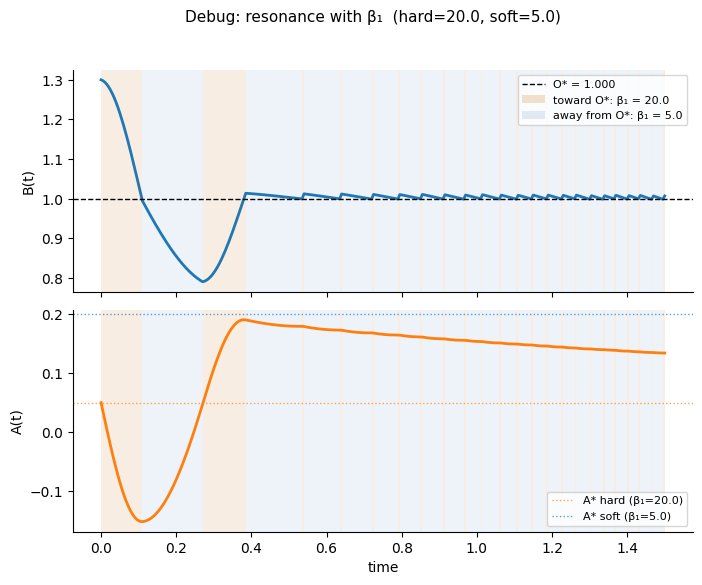

In [198]:
# ── Debug: resonance with beta1 as the switching parameter ───────────────────
# hard = large beta1 (2×), soft = small beta1 (0.5×)
# Shows A(t) and B(t) side by side so we can see what each spring does.

dt_dbg  = 0.005
t_end_dbg = 1.5
O_star  = float(model_if.O_star_sym.subs(model_if._sym_input, model_if.params_base['Input']))

beta1_hard = model_if.params_base['beta1'] * 2.0
beta1_soft = model_if.params_base['beta1'] * 0.5

f_hard_dbg = model_if.get_f({'beta1': beta1_hard})
f_soft_dbg = model_if.get_f({'beta1': beta1_soft})

# Starting state: SS of the hard-spring system, B perturbed upward
rs_dbg = ResonanceStrategy(model_if)
y0_dbg = rs_dbg._eval_ss({'beta1': beta1_hard}).copy()
y0_dbg[model_if.output_idx] *= 1.3   # perturb B

n_steps_dbg = int(round(t_end_dbg / dt_dbg))
t_dbg    = np.linspace(0, t_end_dbg, n_steps_dbg + 1)
y_dbg    = np.zeros((2, n_steps_dbg + 1))
ctrl_dbg = np.zeros(n_steps_dbg + 1)
y_dbg[:, 0] = y0_dbg

use_hard = True
for i in range(n_steps_dbg):
    y_i    = y_dbg[:, i]
    O_i    = y_i[model_if.output_idx]
    dOdt_i = f_hard_dbg(t_dbg[i], y_i)[model_if.output_idx]

    if O_i > O_star:
        use_hard = dOdt_i < 0
    else:
        use_hard = dOdt_i > 0

    ctrl_dbg[i] = beta1_hard if use_hard else beta1_soft
    f_cur = f_hard_dbg if use_hard else f_soft_dbg

    k1 = np.array(f_cur(t_dbg[i],               y_i))
    k2 = np.array(f_cur(t_dbg[i] + 0.5*dt_dbg,  y_i + 0.5*dt_dbg*k1))
    k3 = np.array(f_cur(t_dbg[i] + 0.5*dt_dbg,  y_i + 0.5*dt_dbg*k2))
    k4 = np.array(f_cur(t_dbg[i] +     dt_dbg,   y_i +     dt_dbg*k3))
    y_dbg[:, i+1] = y_i + (dt_dbg / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

ctrl_dbg[-1] = ctrl_dbg[-2]
is_hard_dbg  = np.isclose(ctrl_dbg, beta1_hard)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax_B, ax_A) = plt.subplots(2, 1, figsize=(8, 6), sharex=True,
                                  gridspec_kw={'hspace': 0.08})

for ax in (ax_B, ax_A):
    changes = np.where(np.diff(is_hard_dbg.astype(int)) != 0)[0]
    bounds  = np.concatenate([[0], changes + 1, [len(t_dbg) - 1]])
    for j in range(len(bounds) - 1):
        i0, i1 = bounds[j], bounds[j + 1]
        color  = '#e8c4a0' if is_hard_dbg[i0] else '#c4d8e8'
        ax.axvspan(t_dbg[i0], t_dbg[i1], alpha=0.3, color=color, lw=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax_B.plot(t_dbg, y_dbg[1], color='C0', lw=2)
ax_B.axhline(O_star, color='k', ls='--', lw=1)
ax_B.set_ylabel('B(t)')
ax_B.legend(handles=[
    plt.Line2D([0], [0], color='k',  ls='--', lw=1, label=f'O* = {O_star:.3f}'),
    mpatches.Patch(facecolor='#e8c4a0', alpha=0.5, label=f'toward O*: β₁ = {beta1_hard}'),
    mpatches.Patch(facecolor='#c4d8e8', alpha=0.5, label=f'away from O*: β₁ = {beta1_soft}'),
], fontsize=8, loc='upper right')
plt.setp(ax_B.get_xticklabels(), visible=False)

ax_A.plot(t_dbg, y_dbg[0], color='C1', lw=2)
ax_A.axhline(model_if.params_base['beta2'] / beta1_hard * O_star, color='C1',
             ls=':', lw=1, alpha=0.7, label=f'A* (β₁={beta1_hard})')
ax_A.axhline(model_if.params_base['beta2'] / beta1_soft * O_star, color='C0',
             ls=':', lw=1, alpha=0.7, label=f'A* (β₁={beta1_soft})')
ax_A.set_ylabel('A(t)')
ax_A.set_xlabel('time')
ax_A.legend(handles=[
    plt.Line2D([0], [0], color='C1', ls=':', lw=1, alpha=0.7, label=f'A* hard (β₁={beta1_hard})'),
    plt.Line2D([0], [0], color='C0', ls=':', lw=1, alpha=0.7, label=f'A* soft (β₁={beta1_soft})'),
], fontsize=8, loc='lower right')

fig.suptitle(f'Debug: resonance with β₁  (hard={beta1_hard}, soft={beta1_soft})', fontsize=11)
plt.tight_layout()
plt.show()

In [199]:
class SensitizationStrategy:
    """
    Two-stage sensitization + treatment strategy for an RPAModel.

    Stage 1 — sensitization: linearly ramp the parameter from its baseline
              value to a primed value over ramp_duration time units.
    Stage 2 — treatment: abruptly switch the parameter to the treatment value
              and simulate for t_post time units.

    A control trajectory is also computed: the system holds at the baseline SS
    for the entire ramp phase (no sensitization), then receives the same
    abrupt treatment at the same time.

    Two variants per RPA parameter:
        'up_down': baseline → 2× (slow ramp),  then → 0.5× (abrupt)
        'down_up': baseline → 0.5× (slow ramp), then → 2× (abrupt)

    Results dict keys
    -----------------
    t, y          : time array and sensitized state trajectory
    y_ctrl        : control trajectory (no ramp, direct treatment)
    param_val     : parameter value at every time point (sensitized path)
    base_val, primed_val, treatment_val, ramp_duration, O_star
    """

    def __init__(self, model):
        self.model    = model
        self.baseline = dict(model.params_base)
        self._oidx    = model.output_idx
        self.O_star   = float(self._eval_ss()[self._oidx])
        self.results  = {}

    def _eval_ss(self, overrides=None):
        p = dict(self.baseline)
        if overrides:
            p.update(overrides)
        subs = {sym: p[name]
                for name, sym in zip(self.model._param_names, self.model._sym_params)}
        subs[self.model._sym_input] = p['Input']
        return np.array([float(self.model._ss_dict[s].subs(subs))
                         for s in self.model._sym_state])

    def simulate(self, param, variant='up_down', ramp_duration=10.0,
                 t_post=10.0, dt=0.005):
        """
        Simulate one (param, variant) pair plus a no-ramp control.

        variant : 'up_down' (ramp 1×→2×, treat 0.5×) or
                  'down_up' (ramp 1×→0.5×, treat 2×)
        """
        base_val = self.baseline[param]
        if variant == 'up_down':
            primed_val, treatment_val = base_val * 2.0, base_val * 0.5
        else:
            primed_val, treatment_val = base_val * 0.5, base_val * 2.0

        n_ramp  = int(round(ramp_duration / dt))
        n_post  = int(round(t_post / dt))
        n_total = n_ramp + n_post

        t_arr  = np.linspace(0, ramp_duration + t_post, n_total + 1)
        y_arr  = np.zeros((len(self.model.state_vars), n_total + 1))
        y_ctrl = np.zeros_like(y_arr)
        p_arr  = np.zeros(n_total + 1)

        ss_base          = self._eval_ss()
        y_arr[:, 0]      = ss_base
        y_ctrl[:, 0]     = ss_base
        p_arr[0]         = base_val

        ramp_vals = np.linspace(base_val, primed_val, n_ramp + 1)
        f_treat   = self.model.get_f({param: treatment_val})

        # ── Stage 1: sensitized ramp  /  control holds at baseline SS ────
        for i in range(n_ramp):
            p_i      = ramp_vals[i]
            p_arr[i] = p_i
            f_cur    = self.model.get_f({param: p_i})
            y_i, t_i = y_arr[:, i], t_arr[i]
            k1 = np.array(f_cur(t_i,           y_i))
            k2 = np.array(f_cur(t_i + 0.5*dt,  y_i + 0.5*dt*k1))
            k3 = np.array(f_cur(t_i + 0.5*dt,  y_i + 0.5*dt*k2))
            k4 = np.array(f_cur(t_i + dt,       y_i +      dt*k3))
            y_arr[:, i+1]  = y_i + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
            y_ctrl[:, i+1] = ss_base   # control stays at baseline SS

        # ── Stage 2: both receive the abrupt treatment ─────────────────────
        for i in range(n_ramp, n_total):
            p_arr[i] = treatment_val
            for y_cur_arr in (y_arr, y_ctrl):
                y_i, t_i = y_cur_arr[:, i], t_arr[i]
                k1 = np.array(f_treat(t_i,           y_i))
                k2 = np.array(f_treat(t_i + 0.5*dt,  y_i + 0.5*dt*k1))
                k3 = np.array(f_treat(t_i + 0.5*dt,  y_i + 0.5*dt*k2))
                k4 = np.array(f_treat(t_i + dt,       y_i +      dt*k3))
                y_cur_arr[:, i+1] = y_i + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

        p_arr[n_ramp] = treatment_val
        p_arr[-1]     = treatment_val

        self.results.setdefault(param, {})[variant] = {
            't':             t_arr,
            'y':             y_arr,
            'y_ctrl':        y_ctrl,
            'param_val':     p_arr,
            'base_val':      base_val,
            'primed_val':    primed_val,
            'treatment_val': treatment_val,
            'ramp_duration': ramp_duration,
            'O_star':        self.O_star,
        }
        return t_arr, y_arr

    def simulate_all(self, **kwargs):
        for param in self.model.rpa_params:
            for variant in ('up_down', 'down_up'):
                print(f"  param={param}  variant={variant} ...")
                self.simulate(param, variant=variant, **kwargs)
        print("Done.")


def run_sensitization_demo(model, ramp_duration=10.0, t_post=10.0, dt=0.005):
    """
    Build a SensitizationStrategy for `model`, simulate both variants for
    every RPA parameter, and plot results.

    Each panel overlays the sensitized trajectory and the no-ramp control
    on the same O(t) axis, with matching-color parameter trajectories below.
    """
    ss = SensitizationStrategy(model)
    print(f"Model {model.name}  |  O* = {ss.O_star:.4f}  |  "
          f"RPA params: {model.rpa_params}\n")
    ss.simulate_all(ramp_duration=ramp_duration, t_post=t_post, dt=dt)

    RAMP_COLOR  = '#d0e8d0'
    TREAT_COLOR = '#f0d0d0'

    n = len(model.rpa_params)
    fig = plt.figure(figsize=(14, 5 * n))
    outer = fig.add_gridspec(n, 2, hspace=0.45, wspace=0.3)

    for row, param in enumerate(model.rpa_params):
        for col, variant in enumerate(('up_down', 'down_up')):
            res  = ss.results[param][variant]
            t    = res['t']
            y    = res['y']
            yc   = res['y_ctrl']
            p    = res['param_val']
            t_sw = res['ramp_duration']
            oidx = model.output_idx

            inner = outer[row, col].subgridspec(2, 1, height_ratios=[3, 1],
                                                hspace=0.08)
            ax_O = fig.add_subplot(inner[0])
            ax_p = fig.add_subplot(inner[1], sharex=ax_O)

            for ax in (ax_O, ax_p):
                ax.axvspan(t[0], t_sw,  color=RAMP_COLOR,  alpha=0.4, lw=0)
                ax.axvspan(t_sw, t[-1], color=TREAT_COLOR, alpha=0.4, lw=0)
                ax.axvline(t_sw, color='k', ls=':', lw=0.9, alpha=0.6)
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)

            ax_O.plot(t, y[oidx],  color='steelblue', lw=1.8)
            ax_O.plot(t, yc[oidx], color='tomato',    lw=1.8, ls='--')
            ax_O.axhline(res['O_star'], color='k', ls='--', lw=1)
            ax_O.set_ylabel('O(t)')
            ax_O.legend(handles=[
                plt.Line2D([0], [0], color='steelblue', lw=1.8,
                           label='sensitized'),
                plt.Line2D([0], [0], color='tomato', lw=1.8, ls='--',
                           label='no ramp (control)'),
                plt.Line2D([0], [0], color='k', ls='--', lw=1,
                           label=f"O* = {res['O_star']:.3f}"),
                mpatches.Patch(facecolor=RAMP_COLOR, alpha=0.6,
                               label=f"ramp → {res['primed_val']:.3g}"),
                mpatches.Patch(facecolor=TREAT_COLOR, alpha=0.6,
                               label=f"treat → {res['treatment_val']:.3g}"),
            ], fontsize=7.5)
            ax_O.set_title(
                f"param = {param}  |  {variant.replace('_', '→')}  "
                f"({res['base_val']:.3g} → {res['primed_val']:.3g} → "
                f"{res['treatment_val']:.3g})",
                fontsize=9)
            plt.setp(ax_O.get_xticklabels(), visible=False)

            # Control param: flat at base_val during ramp, then treatment_val
            p_ctrl = np.where(t <= t_sw, res['base_val'], res['treatment_val'])
            ax_p.plot(t, p,      color='steelblue', lw=1.5)
            ax_p.plot(t, p_ctrl, color='tomato',    lw=1.5, ls='--')
            ax_p.set_ylabel(param)
            ax_p.set_xlabel('time')
            yticks = sorted({res['base_val'], res['primed_val'], res['treatment_val']})
            ax_p.set_yticks(yticks)
            ax_p.set_yticklabels([f"{v:.3g}" for v in yticks], fontsize=7)

    fig.suptitle(f'Sensitization strategy — model {model.name}', fontsize=11)
    plt.show()
    return ss

Model f  |  O* = 0.5000  |  RPA params: ['k1', 'k2', 'k3', 'k6', 'k7', 'k8', 'k11', 'k12', 'k13', 'Input']

  param=k1  variant=up_down ...
  param=k1  variant=down_up ...
  param=k2  variant=up_down ...
  param=k2  variant=down_up ...
  param=k3  variant=up_down ...
  param=k3  variant=down_up ...
  param=k6  variant=up_down ...
  param=k6  variant=down_up ...
  param=k7  variant=up_down ...
  param=k7  variant=down_up ...
  param=k8  variant=up_down ...
  param=k8  variant=down_up ...
  param=k11  variant=up_down ...
  param=k11  variant=down_up ...
  param=k12  variant=up_down ...
  param=k12  variant=down_up ...
  param=k13  variant=up_down ...
  param=k13  variant=down_up ...
  param=Input  variant=up_down ...
  param=Input  variant=down_up ...
Done.


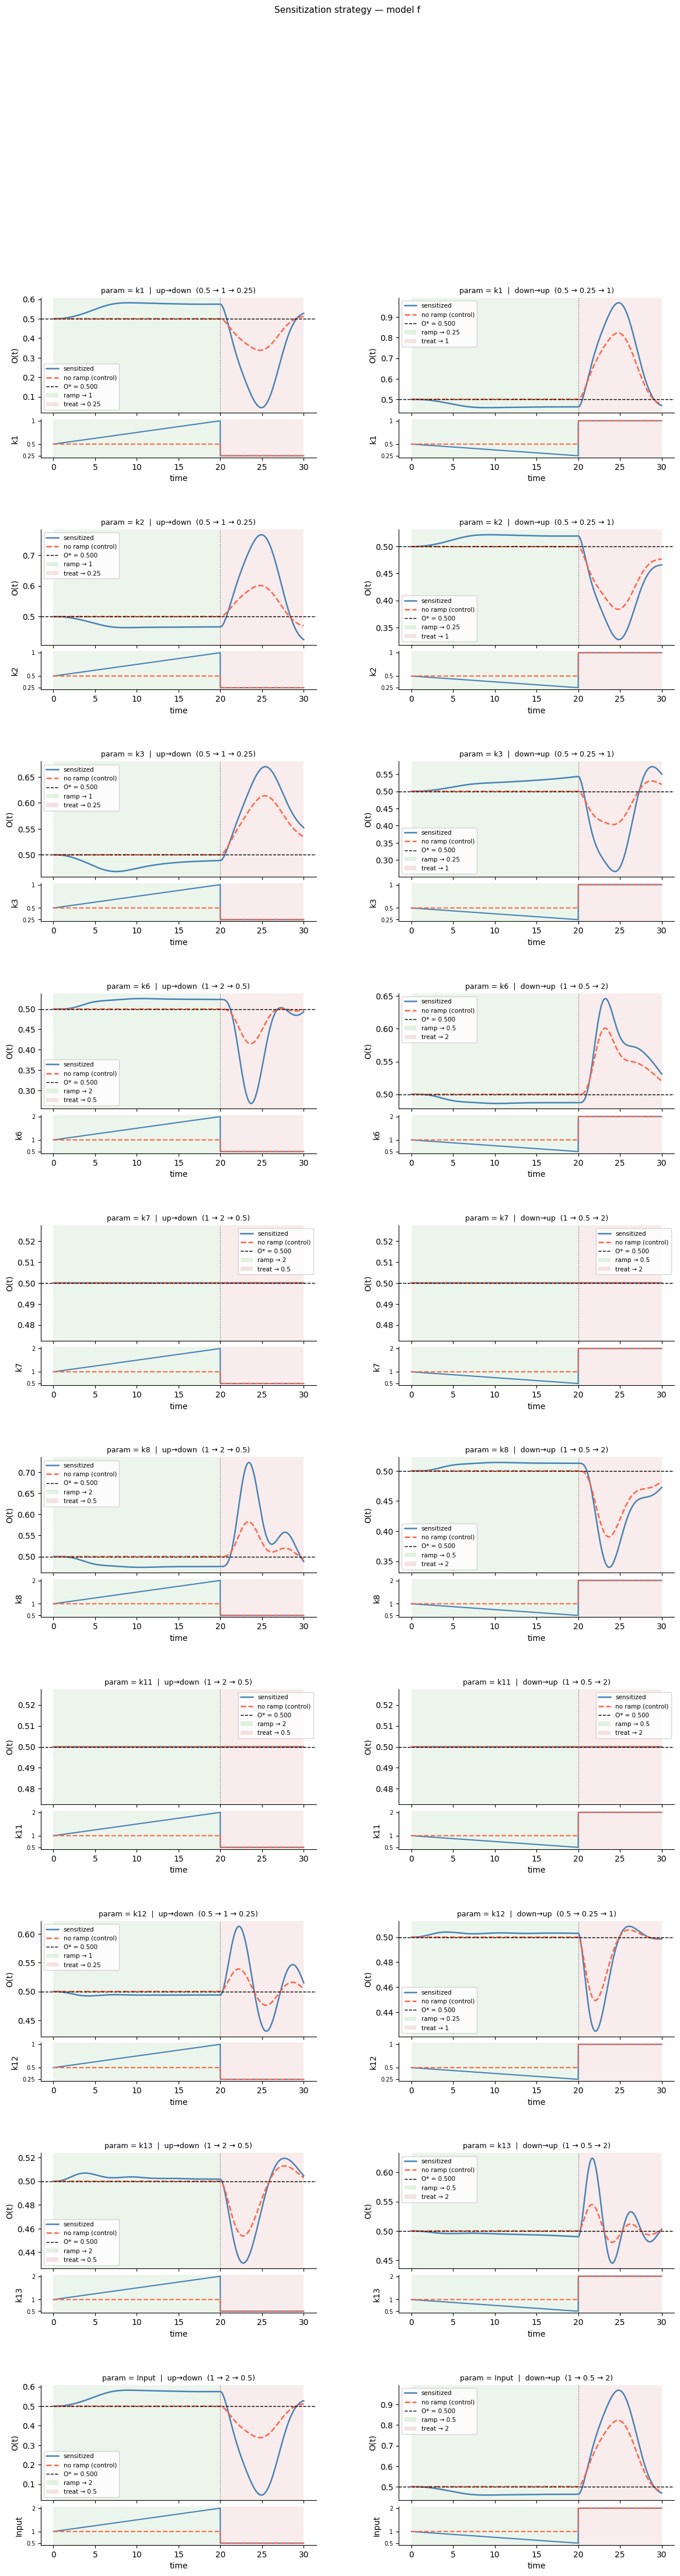

In [208]:
run_sensitization_demo(model_f, ramp_duration=20.0, t_post=10.0)

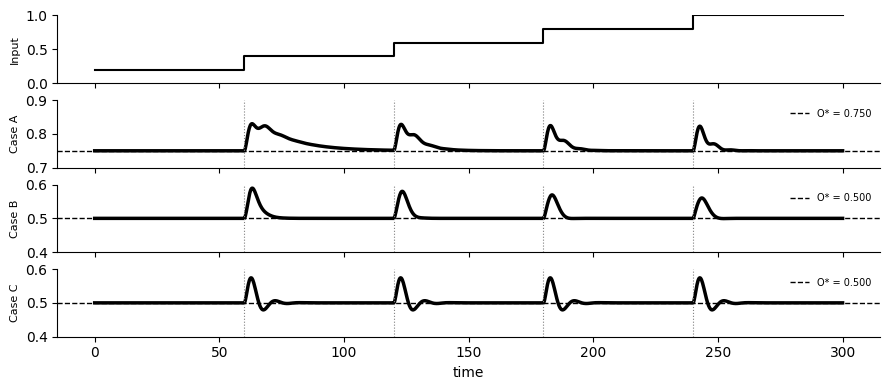

In [201]:
# ── Models a, b, c — stepped input, starting from SS at Input=0.2 ─────────────
input_vals = [0.2, 0.4, 0.6, 0.8, 1.0]
dt         = 60
t_seg      = np.linspace(0, dt, 300)

def stepped_trajectory(model, input_vals, dt, t_seg, y0=None):
    """Single continuous trajectory with piecewise-constant Input steps."""
    if y0 is None:
        y0 = np.ones(len(model.state_vars)) * 0.5
    y_cur, t_offset = y0.copy(), 0.0
    t_all, O_all = [], []
    for inp in input_vals:
        sol = solve_ivp(model.get_f({'Input': inp}), (0, dt), y_cur,
                        t_eval=t_seg, method='Radau', rtol=1e-8, atol=1e-10)
        t_all.append(sol.t + t_offset)
        O_all.append(sol.y[model.output_idx])
        y_cur     = sol.y[:, -1]
        t_offset += dt
    return np.concatenate(t_all), np.concatenate(O_all)

def eval_ss(model, input_val):
    """Evaluate the symbolic steady state at a given Input value."""
    subs = {sym: model.params_base[name]
            for name, sym in zip(model._param_names, model._sym_params)}
    subs[model._sym_input] = input_val
    return np.array([float(model._ss_dict[s].subs(subs)) for s in model._sym_state])

t_stairs = np.repeat(np.arange(len(input_vals) + 1) * dt, 2)[1:-1]
i_stairs = np.repeat(input_vals, 2)
t_vlines = np.arange(1, len(input_vals)) * dt
x_ticks  = np.arange(0, len(input_vals) * dt + 1, 50)

models_abc = [model_a, model_b, model_c]
ylims_abc  = [(0.7, 0.9), (0.4, 0.6), (0.4, 0.6)]
n = len(models_abc)

fig, axes = plt.subplots(n + 1, 1, figsize=(9, (n + 1) * 1.0), sharex=True)

axes[0].plot(t_stairs, i_stairs, color='k', lw=1.5)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Input', fontsize=8)
axes[0].tick_params(labelbottom=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for i, (model, ylim) in enumerate(zip(models_abc, ylims_abc)):
    ax = axes[i + 1]

    y_ss_02 = eval_ss(model, 0.2)
    O_star  = float(y_ss_02[model.output_idx])

    t_cat, O_cat = stepped_trajectory(model, input_vals, dt, t_seg, y0=y_ss_02)

    ax.plot(t_cat, O_cat, color='k', lw=2.5)
    ax.axhline(O_star, color='k', ls='--', lw=1, label=f'O* = {O_star:.3f}')
    for t_v in t_vlines:
        ax.axvline(t_v, color='grey', ls=':', lw=0.8)
    ax.set_ylim(*ylim)
    ax.set_ylabel(f'Case {model.name.upper()}', fontsize=8)
    ax.legend(fontsize=7, frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('time')
axes[-1].set_xticks(x_ticks)
plt.tight_layout(h_pad=0.2)
plt.show()

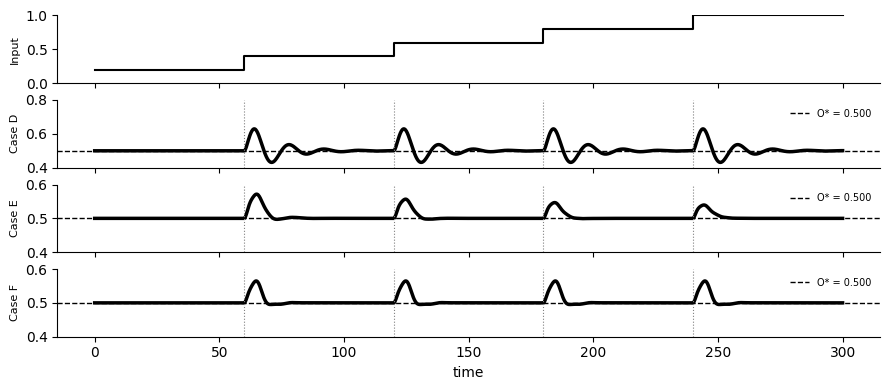

In [202]:
# ── Models d, e, f — stepped input, starting from SS at Input=0.2 ─────────────
models_def = [model_d, model_e, model_f]
ylims_def  = [(0.4, 0.8), (0.4, 0.6), (0.4, 0.6)]
n = len(models_def)

fig, axes = plt.subplots(n + 1, 1, figsize=(9, (n + 1) * 1.0), sharex=True)

axes[0].plot(t_stairs, i_stairs, color='k', lw=1.5)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Input', fontsize=8)
axes[0].tick_params(labelbottom=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for i, (model, ylim) in enumerate(zip(models_def, ylims_def)):
    ax = axes[i + 1]

    y_ss_02 = eval_ss(model, 0.2)
    O_star  = float(y_ss_02[model.output_idx])

    t_cat, O_cat = stepped_trajectory(model, input_vals, dt, t_seg, y0=y_ss_02)

    ax.plot(t_cat, O_cat, color='k', lw=2.5)
    ax.axhline(O_star, color='k', ls='--', lw=1, label=f'O* = {O_star:.3f}')
    for t_v in t_vlines:
        ax.axvline(t_v, color='grey', ls=':', lw=0.8)
    ax.set_ylim(*ylim)
    ax.set_ylabel(f'Case {model.name.upper()}', fontsize=8)
    ax.legend(fontsize=7, frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('time')
axes[-1].set_xticks(x_ticks)
plt.tight_layout(h_pad=0.2)
plt.show()